In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("credit_card_fraud_dataset.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (10000, 16)


,transaction_amount,transaction_hour,account_age_days,distance_km,transactions_24h,avg_amount_7d,device_changes_30d,failed_attempts_24h,num_prior_transactions,is_new_device,email_address_match,billing_shipping_match,card_present,merchant_risk_score,velocity_score,isFraud
0,49.24,9,630,0.47,1,7.48,0,0,40,0,1,1,1,0.216,5.67,0
1,26.09,23,283,9.83,2,17.35,0,0,13,0,1,1,1,0.266,21.47,0
2,57.26,16,1100,23.81,1,21.55,0,0,48,0,1,1,0,0.081,3.90,0
3,137.42,20,187,15.62,1,30.46,1,0,9,0,1,0,1,0.262,34.12,0
4,23.71,1,22,50.86,3,29.28,0,0,1,0,1,1,0,0.026,29.12,0


In [3]:
print("Class Distribution:")
print(df["isFraud"].value_counts())

Class Distribution:
isFraud
0    9648
1     352
Name: count, dtype: int64


In [4]:
fraud_percentage = df["isFraud"].mean() * 100

print(f"Fraud Percentage: {fraud_percentage:.2f}%")

Fraud Percentage: 3.52%


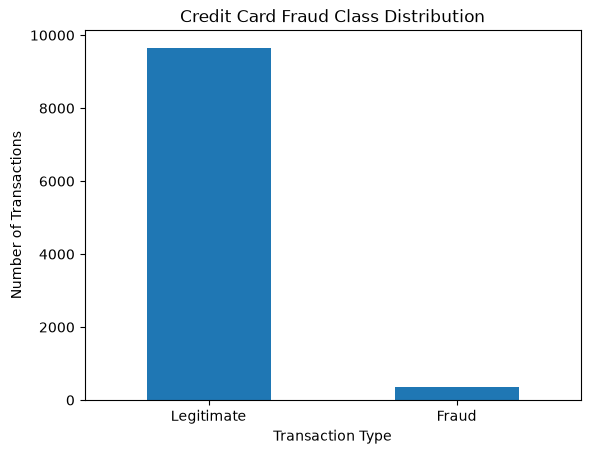

In [5]:
df["isFraud"].value_counts().plot(
    kind="bar"
)

plt.title("Credit Card Fraud Class Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"],
    rotation=0
)

plt.show()

In [6]:
X = df.drop("isFraud", axis=1)

y = df["isFraud"]

In [ ]:
print("Features:", X.shape)
print("Target:", y.shape)
#checked

Features: (10000, 15)
Target: (10000,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
isFraud
0    7718
1     282
Name: count, dtype: int64


In [10]:
smote = SMOTE(
    sampling_strategy=0.5,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [11]:
print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
isFraud
0    7718
1    3859
Name: count, dtype: int64


In [12]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=42
)

In [13]:
model.fit(
    X_train_smote,
    y_train_smote
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [14]:
y_probability = model.predict_proba(
    X_test
)[:, 1]

In [15]:
roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print(f"ROC-AUC: {roc_auc:.3f}")

ROC-AUC: 0.895


In [16]:
pr_auc = average_precision_score(
    y_test,
    y_probability
)

print(f"PR-AUC: {pr_auc:.3f}")

PR-AUC: 0.517


In [17]:
threshold = 0.50

y_pred = (
    y_probability >= threshold
).astype(int)

In [18]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[1866   64]
 [  34   36]]


In [19]:
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Legitimate",
            "Fraud"
        ],
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.97      0.97      1930
       Fraud       0.36      0.51      0.42        70

    accuracy                           0.95      2000
   macro avg       0.67      0.74      0.70      2000
weighted avg       0.96      0.95      0.96      2000



In [20]:
thresholds = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80
]

for threshold in thresholds:

    predictions = (
        y_probability >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.10 | Precision: 0.149 | Recall: 0.800 | F1: 0.251
Threshold: 0.20 | Precision: 0.206 | Recall: 0.757 | F1: 0.324
Threshold: 0.30 | Precision: 0.268 | Recall: 0.686 | F1: 0.386
Threshold: 0.40 | Precision: 0.303 | Recall: 0.571 | F1: 0.396
Threshold: 0.50 | Precision: 0.360 | Recall: 0.514 | F1: 0.424
Threshold: 0.60 | Precision: 0.466 | Recall: 0.486 | F1: 0.476
Threshold: 0.70 | Precision: 0.579 | Recall: 0.471 | F1: 0.520
Threshold: 0.80 | Precision: 0.692 | Recall: 0.386 | F1: 0.495


In [21]:
final_threshold = 0.30

In [22]:
final_prediction = (
    y_probability >= final_threshold
).astype(int)

In [23]:
cm = confusion_matrix(
    y_test,
    final_prediction
)

print("Final Confusion Matrix:")
print(cm)

Final Confusion Matrix:
[[1799  131]
 [  22   48]]


In [24]:
tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)


True Negatives: 1799
False Positives: 131
False Negatives: 22
True Positives: 48


In [25]:
print("\nFinal Classification Report:")

print(
    classification_report(
        y_test,
        final_prediction,
        target_names=[
            "Legitimate",
            "Fraud"
        ],
        zero_division=0
    )
)


Final Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.93      0.96      1930
       Fraud       0.27      0.69      0.39        70

    accuracy                           0.92      2000
   macro avg       0.63      0.81      0.67      2000
weighted avg       0.96      0.92      0.94      2000



In [26]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

print("Feature Importance:")
print(importance)

Feature Importance:
card_present              0.170173
transaction_amount        0.146370
billing_shipping_match    0.094396
velocity_score            0.094018
distance_km               0.058399
merchant_risk_score       0.052686
account_age_days          0.051511
num_prior_transactions    0.051063
failed_attempts_24h       0.050881
transactions_24h          0.042730
is_new_device             0.041027
transaction_hour          0.038371
avg_amount_7d             0.037268
device_changes_30d        0.035971
email_address_match       0.035137
dtype: float32


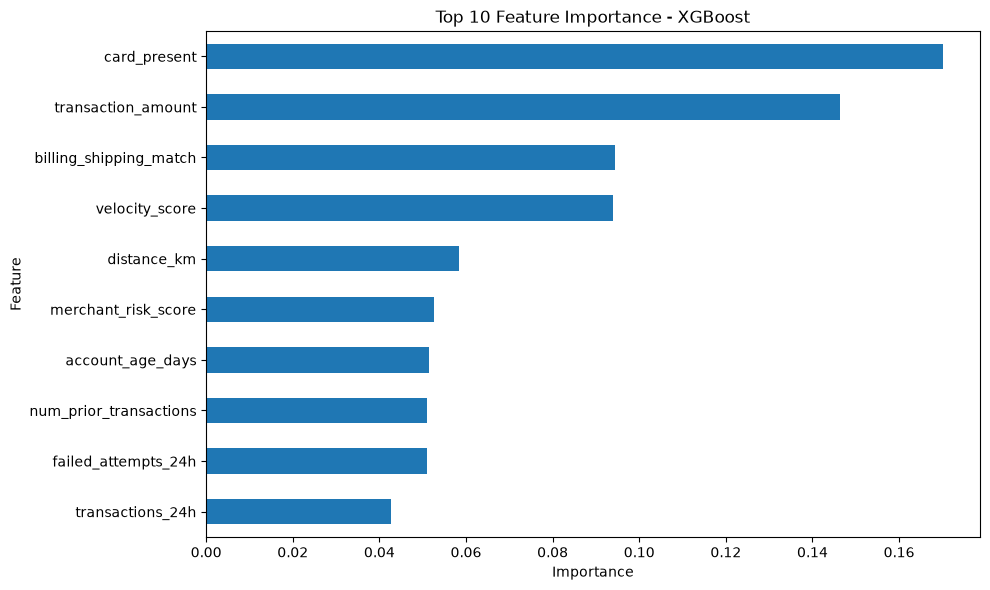

In [27]:
top_features = importance.head(10).sort_values()

plt.figure(figsize=(10, 6))

top_features.plot(
    kind="barh"
)

plt.title("Top 10 Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
precision = precision_score(
    y_test,
    final_prediction,
    zero_division=0
)

recall = recall_score(
    y_test,
    final_prediction,
    zero_division=0
)

f1 = f1_score(
    y_test,
    final_prediction,
    zero_division=0
)

print("========== FINAL RESULTS ==========")

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")
print(f"Final Threshold: {final_threshold:.2f}")

print("\nConfusion Matrix:")
print(cm)

print("\nTrue Positives:", tp)
print("False Positives:", fp)
print("True Negatives:", tn)
print("False Negatives:", fn)

print(f"\nPrecision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")

: 